# Model 1: First deployment

## Data pipeline

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# ==========================================
# 0. Upload + Load 2022–2024 NPZ DATA
# ==========================================
from google.colab import files
uploaded = files.upload()   # upload f1_2022_2024_data.npz from your laptop

npz_fname = list(uploaded.keys())[0]
print("Using NPZ file:", npz_fname)

data = np.load(npz_fname, allow_pickle=True)

X_all = data["X"]          # (N, T, F)  or  (N, W, T, F)
C_all = data["C"]          # team one-hot
y_all = data["y"]          # driver index
teams = data["teams"]
drivers = data["drivers"]

print("Loaded from NPZ:")
print("  X_all.shape:", X_all.shape)
print("  C_all.shape:", C_all.shape)
print("  y_all.shape:", y_all.shape)
print("  #teams:", len(teams))
print("  #drivers:", len(drivers))

# Base dataset (no batching/padding yet)
full_dataset = tf.data.Dataset.from_tensor_slices((X_all, C_all, y_all))

## Error analysis function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import distance
import tensorflow as tf


def run_comprehensive_analysis(model_type, embedder, dataset, team_names, driver_names,
                               batch_size=256, max_batches=200):
    print(f"\n=== ANALYSIS REPORT: {model_type} ===")

    # 1. Data Extraction
    print("Extracting Embeddings...")
    Z_list, y_team_list, y_driver_list = [], [], []

    # Batch the dataset so encoder sees (B, 100, 5), not (100, 5)
    analysis_ds = dataset.batch(batch_size).take(max_batches)

    for batch in analysis_ds:
        # Unpack based on structure
        if len(batch) == 2:      # ((x, c), y)
            (x, c), y = batch
        elif len(batch) == 3:    # (x, c, y)
            x, c, y = batch
        else:
            raise ValueError(f"Unexpected batch structure length: {len(batch)}")

        # ---------- Encoder forward pass ----------
        # For this model, the encoder takes ONLY x: encoder(x) -> [z_mean, z_log_var]
        outputs = embedder(x, training=False)

        # Handle output format (CVAE returns [z_mean, z_log_var])
        if isinstance(outputs, (list, tuple)):
            z = outputs[0]  # z_mean
        else:
            z = outputs     # plain embedding

        # ---------- Labels ----------
        c_np = c.numpy()
        y_np = y.numpy()

        # Teams: c is one-hot of shape (B, num_teams)
        if c_np.ndim == 2:
            t_idx = np.argmax(c_np, axis=1)
        elif c_np.ndim == 1:
            # rare fallback: (num_teams,) → single example
            t_idx = np.array([np.argmax(c_np)])
        else:
            raise ValueError(f"Unexpected c ndim {c_np.ndim}, shape={c_np.shape}")

        # Drivers: y is (B,) of integer ids
        if y_np.ndim == 1:
            d_idx = y_np
        elif y_np.ndim == 0:
            d_idx = np.array([y_np])
        else:
            raise ValueError(f"Unexpected y ndim {y_np.ndim}, shape={y_np.shape}")

        Z_list.append(z.numpy())
        y_team_list.append(t_idx)
        y_driver_list.append(d_idx)

    Z = np.concatenate(Z_list, axis=0)
    y_team = np.concatenate(y_team_list, axis=0)
    y_driver = np.concatenate(y_driver_list, axis=0)

    print(f"Extracted {len(Z)} vectors. Latent Dim: {Z.shape[1]}")

    # 2. Driver Distances (Centroids)
    print("\n[1] Inter-Driver Distances (Centroid L2)")
    unique_drivers = np.unique(y_driver)
    centroids = {d: np.mean(Z[y_driver == d], axis=0) for d in unique_drivers}

    pairs = [('VER', 'HAM'), ('VER', 'PER'), ('HAM', 'BOT')]
    d_map = {name: i for i, name in enumerate(driver_names)}

    for d1_name, d2_name in pairs:
        if d1_name in d_map and d2_name in d_map:
            idx1, idx2 = d_map[d1_name], d_map[d2_name]
            if idx1 in centroids and idx2 in centroids:
                dist = distance.euclidean(centroids[idx1], centroids[idx2])
                print(f"    d({d1_name}, {d2_name}) = {dist:.4f}")

    # 3. t-SNE Visualization
    print("\n[2] Generating t-SNE Plots...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    Z_tsne = tsne.fit_transform(Z)

    plt.figure(figsize=(18, 7))

    # Color by Team
    plt.subplot(1, 2, 1)
    team_labels = [team_names[i] for i in y_team]
    sns.scatterplot(x=Z_tsne[:, 0], y=Z_tsne[:, 1],
                    hue=team_labels, palette='tab10',
                    s=10, alpha=0.6)
    plt.title(f"{model_type}: Latent Space (By Team)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0, fontsize='small')

    # Color by Driver
    plt.subplot(1, 2, 2)
    driver_labels = [driver_names[i] for i in y_driver]
    sns.scatterplot(x=Z_tsne[:, 0], y=Z_tsne[:, 1],
                    hue=driver_labels, palette='tab20',
                    s=10, alpha=0.6)
    plt.title(f"{model_type}: Latent Space (By Driver)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
               borderaxespad=0, fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

    # 4. Adversarial Probing
    print("\n[3] Adversarial Probing")

    # Probe 1: Predict TEAM
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_team, test_size=0.3, random_state=42
    )
    clf_team = LogisticRegression(max_iter=2000)
    clf_team.fit(X_train, y_train)
    acc_team = accuracy_score(y_test, clf_team.predict(X_test))
    print(f"   Team probe accuracy (should be LOW if disentangled): {acc_team:.3f}")

    # Probe 2: Predict DRIVER
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y_driver, test_size=0.3, random_state=42
    )
    clf_driver = LogisticRegression(max_iter=2000)
    clf_driver.fit(X_train, y_train)
    acc_driver = accuracy_score(y_test, clf_driver.predict(X_test))
    print(f"   Driver probe accuracy (should be HIGH if style retained): {acc_driver:.3f}")

## Model 1

In [ ]:
# 0. Upload + Load 2022–2024 NPZ DATA
# ...
X_all, C_all, y_all, teams, drivers
full_dataset = tf.data.Dataset.from_tensor_slices((X_all, C_all, y_all))


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

# ------------------------------------------
# Infer per-sample shapes from full_dataset
# ------------------------------------------
for sample_x, sample_c, sample_y in full_dataset.take(1):
    x_shape = sample_x.shape.as_list()
    c_shape = sample_c.shape.as_list()
    y_shape = sample_y.shape.as_list()

print("sample_x.shape:", x_shape)
print("sample_c.shape:", c_shape)
print("sample_y.shape:", y_shape)

# x can be (T, F) or (W, T, F)
if len(x_shape) == 3:      # (W, T, F)
    SEQ_LEN = x_shape[1]
    FEATURE_DIM = x_shape[2]
elif len(x_shape) == 2:    # (T, F)
    SEQ_LEN = x_shape[0]
    FEATURE_DIM = x_shape[1]
else:
    raise ValueError(f"Unexpected x_shape {x_shape}")

NUM_TEAMS = C_all.shape[1]
NUM_DRIVERS = len(drivers)

print("SEQ_LEN:", SEQ_LEN)
print("FEATURE_DIM:", FEATURE_DIM)
print("NUM_TEAMS:", NUM_TEAMS)
print("NUM_DRIVERS:", NUM_DRIVERS)

# ------------------------------------------
# Split indices for computing team means
# ------------------------------------------
N = X_all.shape[0]
rng = np.random.default_rng(seed=42)
indices = np.arange(N)
rng.shuffle(indices)

train_frac = 0.8
n_train = int(train_frac * N)
train_idx = indices[:n_train]

X_train = X_all[train_idx]      # same shape as X_all[0] per sample
C_train = C_all[train_idx]

# Team indices (train and all)
c_train_idx = np.argmax(C_train, axis=1)
c_all_idx = np.argmax(C_all, axis=1)

# ------------------------------------------
# Compute team means on TRAIN ONLY
# Shape per sample = X_all.shape[1:] (handles both (T,F) and (W,T,F))
# ------------------------------------------
sample_shape = X_all.shape[1:]
team_means = np.zeros((NUM_TEAMS,) + sample_shape, dtype=np.float32)

print("Computing team means on train set...")
for t in range(NUM_TEAMS):
    mask = (c_train_idx == t)
    if np.sum(mask) > 0:
        team_means[t] = X_train[mask].mean(axis=0)
    else:
        print(f"Warning: no train windows for team index {t}, leaving mean as zeros")

# ------------------------------------------
# Apply residualization to ALL data
# ------------------------------------------
print("Applying residualization to all windows...")
X_residual = np.copy(X_all)  # same shape as X_all

for i in range(N):
    t = c_all_idx[i]
    X_residual[i] -= team_means[t]   # broadcast over sample_shape

print("Residuals computed. X_residual.shape:", X_residual.shape)


sample_x.shape: [100, 5]
sample_c.shape: [12]
sample_y.shape: []
SEQ_LEN: 100
FEATURE_DIM: 5
NUM_TEAMS: 12
NUM_DRIVERS: 28
Computing team means on train set...
Applying residualization to all windows...
Residuals computed. X_residual.shape: (415041, 100, 5)


In [ ]:
# ==========================================
# Build residual dataset & training pipeline
# ==========================================

# Dataset with residualized inputs
full_dataset_res = tf.data.Dataset.from_tensor_slices((X_residual, C_all, y_all))

BATCH_SIZE = 256
SHUFFLE_BUFFER = 100_000
EPOCHS = 50

# Padded shapes based on per-sample shapes
# sample_x is either (T, F) or (W, T, F)
if len(x_shape) == 3:       # (W, T, F)
    x_padded_shape = [None, SEQ_LEN, FEATURE_DIM]
elif len(x_shape) == 2:     # (T, F)
    x_padded_shape = [SEQ_LEN, FEATURE_DIM]
else:
    raise ValueError(f"Unexpected x_shape {x_shape}")

# sample_c is (NUM_TEAMS,)
if len(c_shape) == 1:
    c_padded_shape = [NUM_TEAMS]
elif len(c_shape) == 2:
    c_padded_shape = [None, NUM_TEAMS]
else:
    raise ValueError(f"Unexpected c_shape {c_shape}")

# sample_y is scalar ()
if len(y_shape) == 0:
    y_padded_shape = []
elif len(y_shape) == 1:
    y_padded_shape = [None]
else:
    raise ValueError(f"Unexpected y_shape {y_shape}")

print("padded_shapes for x:", x_padded_shape)
print("padded_shapes for c:", c_padded_shape)
print("padded_shapes for y:", y_padded_shape)

train_ds_metric = (
    full_dataset_res
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            x_padded_shape,
            c_padded_shape,
            y_padded_shape,
        ),
        drop_remainder=False,
    )
    .prefetch(tf.data.AUTOTUNE)
)

print("Metric-learning train_ds_metric ready.")


padded_shapes for x: [100, 5]
padded_shapes for c: [12]
padded_shapes for y: []
Metric-learning train_ds_metric ready.


In [ ]:
# ==========================================
# MetricEncoder with same-team triplet loss
# ==========================================
class MetricEncoder(Model):
    def __init__(self, encoder, num_drivers, margin=0.5, lambda_triplet=1.0):
        super().__init__()
        self.encoder = encoder
        self.driver_head = layers.Dense(num_drivers, activation='softmax')
        self.margin = margin
        self.lambda_triplet = lambda_triplet

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.ce_tracker = tf.keras.metrics.Mean(name="ce_loss")
        self.triplet_tracker = tf.keras.metrics.Mean(name="triplet_loss")
        self.acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="acc")

    def call(self, x, training=False):
        z = self.encoder(x, training=training)
        if isinstance(z, (list, tuple)):
            z = z[0]
        logits = self.driver_head(z)
        return z, logits

    def train_step(self, data):
        # data = (x_batch, c_batch, y_batch)
        x, c, y = data

        # Handle (B, W, T, F) -> flatten windows to (B*W, T, F)
        if len(x.shape) == 4:
            B = tf.shape(x)[0]
            W = tf.shape(x)[1]
            x = tf.reshape(x, [B * W, x.shape[2], x.shape[3]])

            # Repeat c and y along W
            if len(c.shape) == 2:   # (B, NUM_TEAMS)
                c = tf.repeat(c, repeats=W, axis=0)
            if len(y.shape) == 1:   # (B,)
                y = tf.repeat(y, repeats=W, axis=0)

        with tf.GradientTape() as tape:
            # 1) Forward pass
            z, logits = self(x, training=True)

            # 2) Supervised CE loss
            ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y, logits)
            ce_loss = tf.reduce_mean(ce_loss)

            # 3) Triplet loss
            z_norm = tf.math.l2_normalize(z, axis=1)  # (N, D)
            scores = tf.matmul(z_norm, z_norm, transpose_b=True)
            dists = 2.0 - 2.0 * scores   # distances in [0,4]

            # Labels
            y_int = tf.cast(y, tf.int32)
            c_idx = tf.argmax(c, axis=1)
            c_idx = tf.cast(c_idx, tf.int32)

            # Positives: same driver, not self
            mask_pos = tf.cast(tf.equal(y_int[:, None], y_int[None, :]), tf.float32)
            mask_pos = mask_pos - tf.eye(tf.shape(z)[0])

            # Negatives: same team, different driver
            mask_team = tf.cast(tf.equal(c_idx[:, None], c_idx[None, :]), tf.float32)
            mask_diff_driver = 1.0 - mask_pos - tf.eye(tf.shape(z)[0])
            mask_hard_neg = mask_team * mask_diff_driver

            # Hardest positive: max distance among positives
            pos_dists = dists * mask_pos
            hardest_pos = tf.reduce_max(pos_dists, axis=1)

            # Hardest negative: min distance among valid negatives
            neg_dists = dists + 1e6 * (1.0 - mask_hard_neg)
            hardest_neg = tf.reduce_min(neg_dists, axis=1)

            # Triplet hinge
            raw_triplet = tf.maximum(hardest_pos - hardest_neg + self.margin, 0.0)

            # Valid anchors: need at least one positive AND one same-team negative
            has_pos = tf.reduce_sum(mask_pos, axis=1) > 0
            has_neg = tf.reduce_sum(mask_hard_neg, axis=1) > 0
            valid_anchors = tf.cast(tf.logical_and(has_pos, has_neg), tf.float32)
            num_valid = tf.reduce_sum(valid_anchors) + 1e-8

            triplet_loss = tf.reduce_sum(raw_triplet * valid_anchors) / num_valid

            total_loss = ce_loss + self.lambda_triplet * triplet_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(total_loss)
        self.ce_tracker.update_state(ce_loss)
        self.triplet_tracker.update_state(triplet_loss)
        self.acc_metric.update_state(y, logits)

        return {
            "loss": self.loss_tracker.result(),
            "ce": self.ce_tracker.result(),
            "triplet": self.triplet_tracker.result(),
            "acc": self.acc_metric.result(),
        }

    @property
    def metrics(self):
        return [self.loss_tracker, self.ce_tracker, self.triplet_tracker, self.acc_metric]


# ==========================================
# Build encoder (same as your Model 1)
# ==========================================
def build_simple_encoder(seq_len, feature_dim, latent_dim):
    x_in = layers.Input(shape=(seq_len, feature_dim), name="x_in")
    h = layers.Conv1D(32, 3, strides=2, padding="same", activation="relu")(x_in)
    h = layers.Conv1D(64, 3, strides=2, padding="same", activation="relu")(h)
    h = layers.Flatten()(h)
    h = layers.Dense(128, activation="relu")(h)
    z = layers.Dense(latent_dim, name="z")(h)
    return Model(x_in, z, name="encoder")


print("Building Model 4 (Metric Learning)...")
encoder_model = build_simple_encoder(SEQ_LEN, FEATURE_DIM, latent_dim=10)

model_metric = MetricEncoder(
    encoder=encoder_model,
    num_drivers=NUM_DRIVERS,
    margin=0.5,
    lambda_triplet=2.0,   # you can tune 1–5
)

model_metric.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

print("Starting training for Model 4...")
history_metric = model_metric.fit(train_ds_metric, epochs=EPOCHS)


Building Model 4 (Metric Learning)...
Starting training for Model 4...
Epoch 1/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - acc: 0.1682 - ce: 2.7109 - loss: 3.7473 - triplet: 0.5182
Epoch 2/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5086 - ce: 1.2346 - loss: 2.2625 - triplet: 0.5139
Epoch 3/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5560 - ce: 1.0542 - loss: 2.0794 - triplet: 0.5126
Epoch 4/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5800 - ce: 0.9722 - loss: 1.9965 - triplet: 0.5121
Epoch 5/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.5980 - ce: 0.9158 - loss: 1.9394 - triplet: 0.5118
Epoch 6/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.6057 - ce: 0.8889 - loss: 1.9123 - triplet: 0.5117
Epoch 7/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.6193 - ce: 0.8509 - loss: 1.8732 - triplet: 0.5111
Epoch 8/50
1622/1622 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.6262 - ce: 0.8266 - loss: 1.8480 - triplet: 0.5107
Epoch 9/50
1622/


Running analysis for Model 4 (Metric + Residual)...

=== ANALYSIS REPORT: Model 4: Metric Learning (Triplet + Team-Residualized Inputs) ===
Extracting Embeddings...
Extracted 51200 vectors. Latent Dim: 10

[1] Inter-Driver Distances (Centroid L2)
    d(VER, HAM) = 33.4564
    d(VER, PER) = 3.1186
    d(HAM, BOT) = 94.9496

[2] Generating t-SNE Plots...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


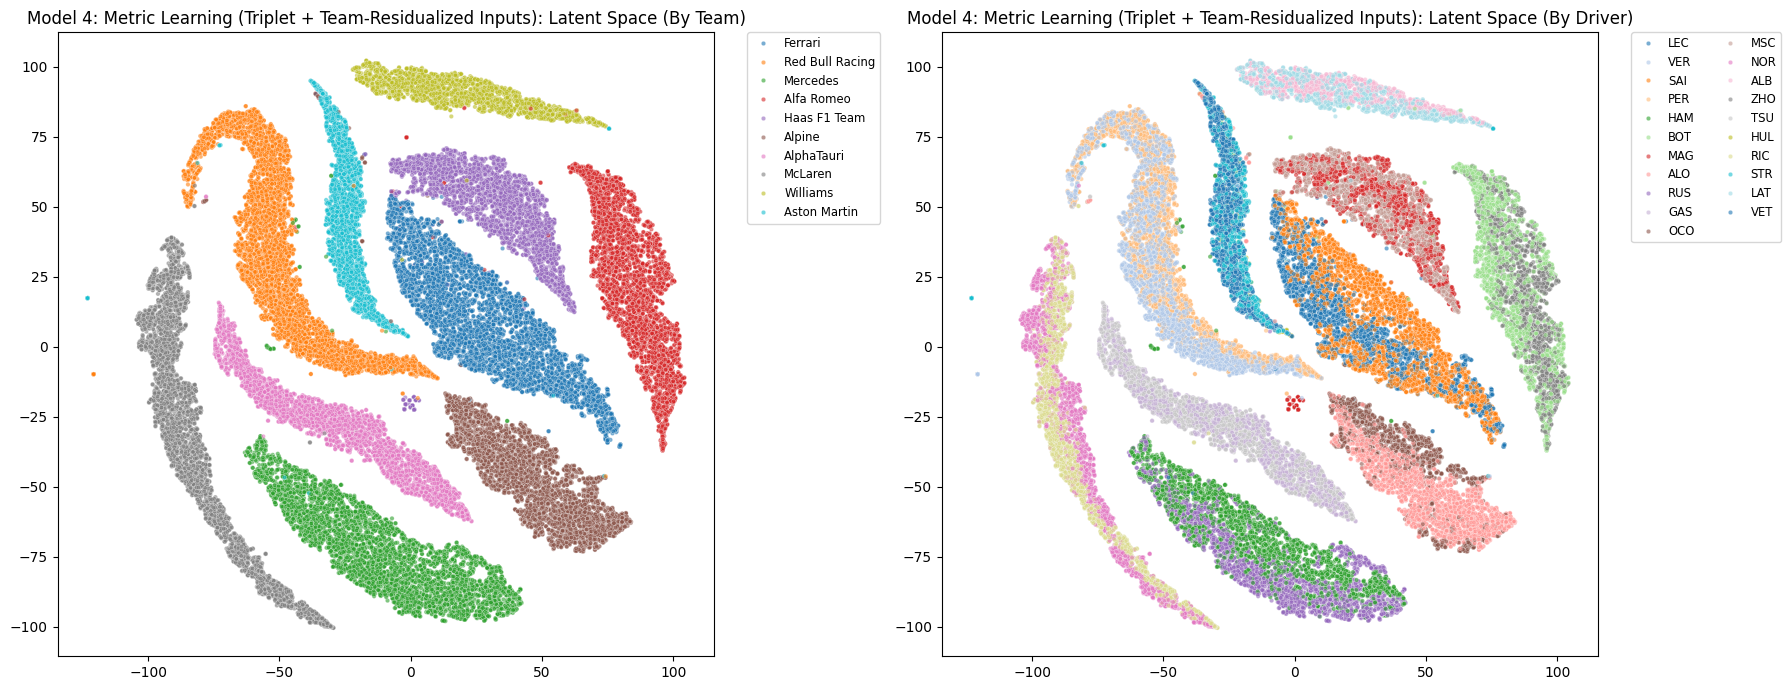


[3] Adversarial Probing
   Team probe accuracy (should be LOW if disentangled): 0.997
   Driver probe accuracy (should be HIGH if style retained): 0.815


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("\nRunning analysis for Model 4 (Metric + Residual)...")

run_comprehensive_analysis(
    model_type="Model 4: Metric Learning (Triplet + Team-Residualized Inputs)",
    embedder=model_metric,
    dataset=full_dataset_res,      # use residual dataset
    team_names=teams,
    driver_names=drivers,
)
